# CDS524 Assignment 1 — Risky GridWorld (Q-learning)

This notebook contains the **training + evaluation** part of my project.

What you will find here:
- A custom GridWorld environment (walls + traps + moving enemy)
- A tabular **Q-learning** agent (epsilon-greedy)
- Training curves (return + success rate)
- An ablation on **reward shaping**
- A greedy rollout demo + exported artifacts (**qtable.pkl**, metrics CSV, GIF)

> The interactive (playable) UI demo is in a separate Python file: `524_ui_clean.py`.


## 1. Environment

I implement a small 8×8 GridWorld with:
- **Start** at (0,0) and **Goal** at (7,7)
- **Walls** (obstacles): invalid moves are penalized
- **Traps**: terminal states with a large negative reward
- **Enemy**: moves randomly after the agent; collision ends the episode

The state for the *basic* environment is `(agent_row, agent_col)`; later I extend it to include the enemy position.

In [1]:
import numpy as np
from dataclasses import dataclass

@dataclass(frozen=True)
class StepResult:
    next_state: tuple
    reward: float
    done: bool
    info: dict

class GridWorld:
    """
    GridWorld (discrete):
      state: (r, c)
      actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT, 4=STAY
    """
    UP, DOWN, LEFT, RIGHT, STAY = 0, 1, 2, 3, 4

    def __init__(
        self,
        grid_size=8,
        obstacle_prob=0.15,
        seed=42,
        step_reward=-0.1,
        goal_reward=20.0,
        invalid_penalty=-1.0,
        max_obstacle_tries=5000
    ):
        self.grid_size = int(grid_size)
        self.rng = np.random.default_rng(seed)

        self.step_reward = float(step_reward)
        self.goal_reward = float(goal_reward)
        self.invalid_penalty = float(invalid_penalty)

        self.actions = [self.UP, self.DOWN, self.LEFT, self.RIGHT, self.STAY]
        self.action_to_delta = {
            self.UP: (-1, 0),
            self.DOWN: (1, 0),
            self.LEFT: (0, -1),
            self.RIGHT: (0, 1),
            self.STAY: (0, 0),
        }

        # fixed start/goal for reproducibility
        self.start = (0, 0)
        self.goal = (self.grid_size - 1, self.grid_size - 1)

        # generate obstacles but ensure path exists
        self.obstacles = set()
        self._generate_obstacles(obstacle_prob, max_obstacle_tries)

        self.state = self.start

    def _in_bounds(self, rc):
        r, c = rc
        return 0 <= r < self.grid_size and 0 <= c < self.grid_size

    def _is_blocked(self, rc):
        return rc in self.obstacles

    def _neighbors(self, rc):
        r, c = rc
        for a in [self.UP, self.DOWN, self.LEFT, self.RIGHT]:
            dr, dc = self.action_to_delta[a]
            nxt = (r + dr, c + dc)
            if self._in_bounds(nxt) and (nxt not in self.obstacles):
                yield nxt

    def _has_path(self):
        # BFS from start to goal
        from collections import deque
        q = deque([self.start])
        seen = {self.start}
        while q:
            cur = q.popleft()
            if cur == self.goal:
                return True
            for nxt in self._neighbors(cur):
                if nxt not in seen:
                    seen.add(nxt)
                    q.append(nxt)
        return False

    def _generate_obstacles(self, obstacle_prob, max_tries):
        # Keep start/goal free
        all_cells = [(r, c) for r in range(self.grid_size) for c in range(self.grid_size)]
        candidates = [x for x in all_cells if x not in (self.start, self.goal)]

        for _ in range(max_tries):
            self.obstacles.clear()
            for cell in candidates:
                if self.rng.random() < obstacle_prob:
                    self.obstacles.add(cell)
            if self._has_path():
                return
        # If it fails, just keep no obstacles (safe fallback)
        self.obstacles.clear()

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action: int) -> StepResult:
        r, c = self.state
        dr, dc = self.action_to_delta[int(action)]
        nxt = (r + dr, c + dc)

        # invalid move: out of bounds or into obstacle
        if (not self._in_bounds(nxt)) or self._is_blocked(nxt):
            return StepResult(next_state=self.state, reward=self.invalid_penalty, done=False, info={"invalid": True})

        self.state = nxt

        if self.state == self.goal:
            return StepResult(next_state=self.state, reward=self.goal_reward, done=True, info={"goal": True})

        return StepResult(next_state=self.state, reward=self.step_reward, done=False, info={})

    def render_ascii(self):
        # quick colab-friendly render
        grid = [["." for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        for (r, c) in self.obstacles:
            grid[r][c] = "#"
        sr, sc = self.start
        gr, gc = self.goal
        ar, ac = self.state
        grid[sr][sc] = "S"
        grid[gr][gc] = "G"
        grid[ar][ac] = "A"
        return "\n".join(" ".join(row) for row in grid)

# quick sanity test
env = GridWorld(grid_size=8, obstacle_prob=0.2, seed=1)
print(env.render_ascii())
print("Start:", env.reset())
out = env.step(env.RIGHT)
print("Step:", out)
print(env.render_ascii())

A . . . . . . .
. # . . . . # .
. . . . . . . .
# . # . . . # .
# . . # . . . .
. . . . . . # .
. . # . . . # .
. . . . . . . G
Start: (0, 0)
Step: StepResult(next_state=(0, 1), reward=-0.1, done=False, info={})
S A . . . . . .
. # . . . . # .
. . . . . . . .
# . # . . . # .
# . . # . . . .
. . . . . . # .
. . # . . . # .
. . . . . . . G


## 2. Q-learning agent

A standard tabular Q-learning agent with epsilon-greedy exploration.

I store the Q-table as a Python dict: `Q[state] -> np.array(|A|)`.
That makes it easy to handle sparse state visitation (especially once the enemy is included).

In [2]:
import numpy as np
from dataclasses import dataclass

@dataclass
class QLearningAgent:
    actions: list
    alpha: float = 0.1
    gamma: float = 0.95
    epsilon: float = 1.0
    epsilon_min: float = 0.05
    epsilon_decay: float = 0.995

    def __post_init__(self):
        # Q-table as dict: Q[(state)][action] -> value
        self.Q = {}  # { (r,c): np.array(len(actions)) }

    def _ensure_state(self, state):
        if state not in self.Q:
            self.Q[state] = np.zeros(len(self.actions), dtype=np.float32)

    def act(self, state):
        """epsilon-greedy action selection"""
        self._ensure_state(state)
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        return int(np.argmax(self.Q[state]))

    def update(self, s, a, r, s_next, done):
        """Q(s,a) <- Q(s,a) + alpha * (r + gamma*max Q(s',.) - Q(s,a))"""
        self._ensure_state(s)
        self._ensure_state(s_next)

        a_idx = self.actions.index(a)

        best_next = 0.0 if done else float(np.max(self.Q[s_next]))
        td_target = r + self.gamma * best_next
        td_error = td_target - float(self.Q[s][a_idx])
        self.Q[s][a_idx] = float(self.Q[s][a_idx] + self.alpha * td_error)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# quick sanity test (one step update)
agent = QLearningAgent(actions=env.actions, alpha=0.2, gamma=0.95, epsilon=1.0)
s = env.reset()
a = agent.act(s)
res = env.step(a)
agent.update(s, a, res.reward, res.next_state, res.done)
agent.decay_epsilon()

print("Sample state:", s)
print("Action taken:", a, "Epsilon now:", agent.epsilon)
print("Q[s] =", agent.Q[s])

Sample state: (0, 0)
Action taken: 0 Epsilon now: 0.995
Q[s] = [-0.2  0.   0.   0.   0. ]


## 3. Training loop + metrics

During training I log:
- episodic **return**
- number of **steps**
- **success** (reached goal)
- end reason (`goal/trap/enemy/timeout`)

I also compute moving averages for smoother plots.

Episode 200/800  return=17.20  steps=20  eps=0.367  end=goal
Episode 400/800  return=18.70  steps=14  eps=0.135  end=goal
Episode 600/800  return=18.70  steps=14  eps=0.050  end=goal
Episode 800/800  return=18.70  steps=14  eps=0.050  end=goal
saved metrics_v1.csv


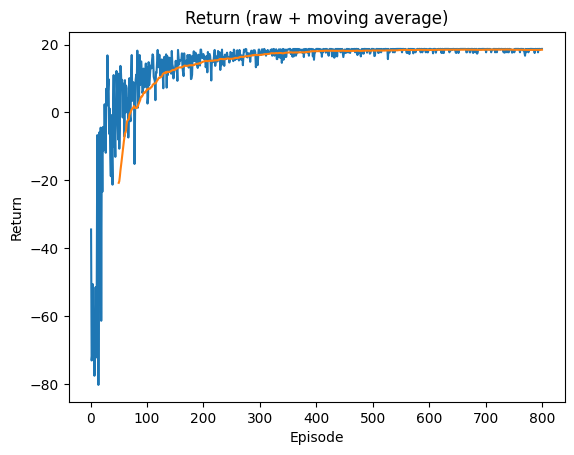

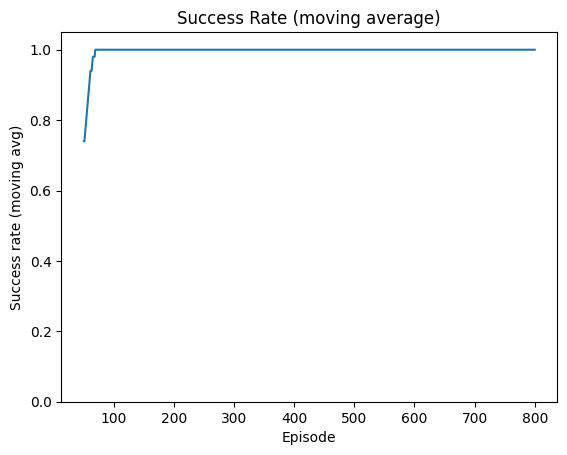

,episode,return,steps,success,end_reason,return_ma,success_rate_ma
795,796,18.7,14,1,goal,18.424,1.0
796,797,18.5,16,1,goal,18.442,1.0
797,798,18.7,14,1,goal,18.462,1.0
798,799,18.7,14,1,goal,18.466,1.0
799,800,18.7,14,1,goal,18.470,1.0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def train_qlearning(
    env,
    agent,
    num_episodes=800,
    max_steps=200,
    reward_avg_window=50,
    seed=0
):
    rng = np.random.default_rng(seed)
    returns = []
    steps_list = []
    success_list = []
    end_reason = []  # "goal" / "trap" / "enemy" / "timeout"

    for ep in range(num_episodes):
        s = env.reset()
        total_r = 0.0

        reason = "timeout"
        success = 0

        for t in range(max_steps):
            # epsilon-greedy
            if rng.random() < agent.epsilon:
                a = int(rng.choice(agent.actions))
            else:
                agent._ensure_state(s)
                a = int(agent.actions[int(np.argmax(agent.Q[s]))])

            res = env.step(a)
            agent.update(s, a, res.reward, res.next_state, res.done)

            total_r += res.reward
            s = res.next_state

            if res.done:
                # success: ONLY goal
                if res.info.get("goal", False):
                    success = 1
                    reason = "goal"
                elif res.info.get("trap", False):
                    success = 0
                    reason = "trap"
                elif res.info.get("enemy", False):
                    success = 0
                    reason = "enemy"
                else:
                    success = 0
                    reason = "done_other"
                break

        agent.decay_epsilon()

        returns.append(total_r)
        steps_list.append(t + 1)
        success_list.append(success)
        end_reason.append(reason)

        if (ep + 1) % 200 == 0:
            print(f"Episode {ep+1}/{num_episodes}  return={total_r:.2f}  steps={t+1}  eps={agent.epsilon:.3f}  end={reason}")

    df = pd.DataFrame({
        "episode": np.arange(1, num_episodes+1),
        "return": returns,
        "steps": steps_list,
        "success": success_list,
        "end_reason": end_reason
    })
    df["return_ma"] = df["return"].rolling(reward_avg_window).mean()
    df["success_rate_ma"] = df["success"].rolling(reward_avg_window).mean()
    return df

# train
env2 = GridWorld(grid_size=8, obstacle_prob=0.2, seed=1)  # 固定seed，便于对比实验
agent2 = QLearningAgent(actions=env2.actions, alpha=0.2, gamma=0.95, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995)

df = train_qlearning(env2, agent2, num_episodes=800, max_steps=200, reward_avg_window=50, seed=1)

# save CSV
df.to_csv("metrics_v1.csv", index=False)
print("saved metrics_v1.csv")

# plot return curve
plt.figure()
plt.plot(df["episode"], df["return"])
plt.plot(df["episode"], df["return_ma"])
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return (raw + moving average)")
plt.show()

# plot success rate curve
plt.figure()
plt.plot(df["episode"], df["success_rate_ma"])
plt.xlabel("Episode")
plt.ylabel("Success rate (moving avg)")
plt.title("Success Rate (moving average)")
plt.ylim(0, 1.05)
plt.show()

df.tail()

## 4. RiskyGridWorld (enemy + traps)

To make the task less trivial (and more "game-like"), I extend the environment:
- traps remain terminal
- an enemy moves after the agent

Now the state becomes:

`(agent_r, agent_c, enemy_r, enemy_c)`

This is the same state representation used later in the **pygame interactive demo**.

In [4]:
from dataclasses import dataclass

@dataclass(frozen=True)
class StepResult:
    next_state: tuple
    reward: float
    done: bool
    info: dict

class RiskyGridWorld(GridWorld):
    """
    Extends GridWorld:
      - traps: stepping onto trap ends episode with big penalty
      - enemy: moves each step; collision ends episode with big penalty
      - state: (agent_r, agent_c, enemy_r, enemy_c)
    """

    def __init__(
        self,
        grid_size=8,
        obstacle_prob=0.15,
        trap_prob=0.05,
        enemy_enabled=True,
        enemy_policy="random",  # "random" or "patrol"
        seed=42,
        step_reward=-0.1,
        goal_reward=20.0,
        invalid_penalty=-1.0,
        trap_penalty=-20.0,
        enemy_penalty=-20.0,
        max_obstacle_tries=5000
    ):
        super().__init__(
            grid_size=grid_size,
            obstacle_prob=obstacle_prob,
            seed=seed,
            step_reward=step_reward,
            goal_reward=goal_reward,
            invalid_penalty=invalid_penalty,
            max_obstacle_tries=max_obstacle_tries
        )

        self.trap_penalty = float(trap_penalty)
        self.enemy_penalty = float(enemy_penalty)

        self.enemy_enabled = bool(enemy_enabled)
        self.enemy_policy = str(enemy_policy)

        # generate traps (not on start/goal/obstacle)
        self.traps = set()
        self._generate_traps(trap_prob)

        # enemy init
        self.enemy = None
        self._enemy_patrol_dir = 1  # for patrol
        self._place_enemy()

    def _free_cells(self):
        cells = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                rc = (r, c)
                if rc in self.obstacles:
                    continue
                if rc == self.start or rc == self.goal:
                    continue
                cells.append(rc)
        return cells

    def _generate_traps(self, trap_prob):
        self.traps.clear()
        for cell in self._free_cells():
            if cell == self.start or cell == self.goal:
                continue
            if self.rng.random() < trap_prob:
                self.traps.add(cell)

        # safety: do not block path existence too much
        # (traps are allowed on path; they are "risky", not walls)

    def _place_enemy(self):
        if not self.enemy_enabled:
            self.enemy = None
            return
        free = [c for c in self._free_cells() if c not in self.traps]
        # also avoid spawning on agent
        free = [c for c in free if c != self.start]
        self.enemy = free[int(self.rng.integers(0, len(free)))] if free else (self.grid_size-1, 0)

    def reset(self):
        self.state = self.start
        self._place_enemy()
        return self._get_state()

    def _get_state(self):
        ar, ac = self.state
        if self.enemy_enabled and self.enemy is not None:
            er, ec = self.enemy
        else:
            er, ec = (-1, -1)
        return (ar, ac, er, ec)

    def _enemy_move(self):
        if not self.enemy_enabled or self.enemy is None:
            return

        er, ec = self.enemy

        # Patrol policy: move left-right on same row if possible
        if self.enemy_policy == "patrol":
            # try move horizontally
            candidates = [(er, ec + self._enemy_patrol_dir)]
            nxt = candidates[0]
            if (not self._in_bounds(nxt)) or (nxt in self.obstacles) or (nxt == self.goal) or (nxt == self.start):
                self._enemy_patrol_dir *= -1
                nxt = (er, ec + self._enemy_patrol_dir)
            if self._in_bounds(nxt) and (nxt not in self.obstacles) and (nxt != self.goal) and (nxt != self.start):
                self.enemy = nxt
            return

        # Random policy: choose a random legal move (including stay)
        moves = []
        for a in [self.UP, self.DOWN, self.LEFT, self.RIGHT, self.STAY]:
            dr, dc = self.action_to_delta[a]
            nxt = (er + dr, ec + dc)
            if not self._in_bounds(nxt):
                continue
            if nxt in self.obstacles:
                continue
            if nxt == self.goal or nxt == self.start:
                continue
            moves.append(nxt)
        if moves:
            self.enemy = moves[int(self.rng.integers(0, len(moves)))]

    def step(self, action: int) -> StepResult:
        # 1) agent moves using base rules
        base = super().step(action)

        # base step might be invalid (state unchanged)
        ar, ac = self.state

        # 2) trap check (after agent move)
        if (ar, ac) in self.traps:
            return StepResult(
                next_state=self._get_state(),
                reward=self.trap_penalty,
                done=True,
                info={**base.info, "trap": True}
            )

        # 3) if already reached goal in base step, finish
        if base.done:
            return StepResult(
                next_state=self._get_state(),
                reward=base.reward,
                done=True,
                info=base.info
            )

        # 4) enemy moves
        self._enemy_move()

        # 5) collision check
        if self.enemy_enabled and self.enemy == (ar, ac):
            return StepResult(
                next_state=self._get_state(),
                reward=self.enemy_penalty,
                done=True,
                info={**base.info, "enemy": True}
            )

        # 6) normal step
        return StepResult(
            next_state=self._get_state(),
            reward=base.reward,
            done=False,
            info=base.info
        )

    def render_ascii(self):
        grid = [["." for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        for (r, c) in self.obstacles:
            grid[r][c] = "#"
        for (r, c) in self.traps:
            grid[r][c] = "T"

        sr, sc = self.start
        gr, gc = self.goal
        ar, ac = self.state
        grid[sr][sc] = "S"
        grid[gr][gc] = "G"

        if self.enemy_enabled and self.enemy is not None:
            er, ec = self.enemy
            grid[er][ec] = "E"

        grid[ar][ac] = "A"
        return "\n".join(" ".join(row) for row in grid)

In [5]:
env_r = RiskyGridWorld(
    grid_size=8,
    obstacle_prob=0.2,
    trap_prob=0.2,
    enemy_enabled=True,
    enemy_policy="random",
    seed=1,
    trap_penalty=-25,
    enemy_penalty=-25
)
print(env_r.render_ascii())
s = env_r.reset()
print("Initial state:", s)

A E . T . . . .
. # . . . . # .
. . . T . . T .
# . # . . . # T
# . . # . . T .
T . . . . . # .
. . # . . . # .
. . . . . . . G
Initial state: (0, 0, 0, 1)


In [6]:
print("Number of traps:", len(env_r.traps))
print("Trap positions:", env_r.traps)

Number of traps: 6
Trap positions: {(3, 7), (0, 3), (4, 6), (2, 3), (2, 6), (5, 0)}


In [7]:
env3 = RiskyGridWorld(
    grid_size=8,
    obstacle_prob=0.2,
    trap_prob=0.2,
    enemy_enabled=True,
    enemy_policy="random",
    seed=1,
    step_reward=-0.1,
    goal_reward=20.0,
    invalid_penalty=-1.0,
    trap_penalty=-25.0,
    enemy_penalty=-25.0
)

agent3 = QLearningAgent(actions=env3.actions, alpha=0.2, gamma=0.95,
                        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995)

df_risky = train_qlearning(env3, agent3, num_episodes=1200, max_steps=300, reward_avg_window=80, seed=1)

df_risky.to_csv("metrics_risky.csv", index=False)
print("Saved metrics_risky.csv")

Episode 200/1200  return=-29.70  steps=12  eps=0.367  end=trap
Episode 400/1200  return=-27.40  steps=16  eps=0.135  end=trap
Episode 600/1200  return=-27.80  steps=20  eps=0.050  end=enemy
Episode 800/1200  return=-42.90  steps=108  eps=0.050  end=enemy
Episode 1000/1200  return=-26.70  steps=18  eps=0.050  end=trap
Episode 1200/1200  return=10.60  steps=86  eps=0.050  end=goal
Saved metrics_risky.csv


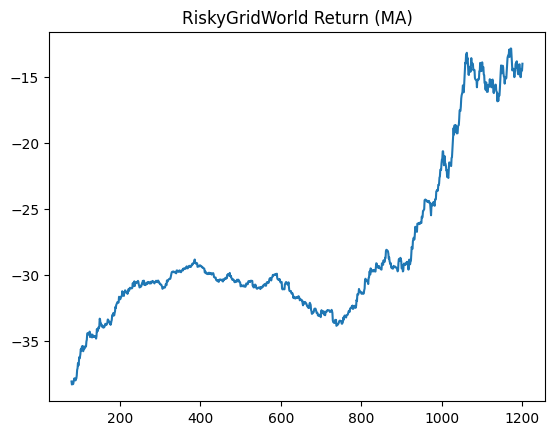

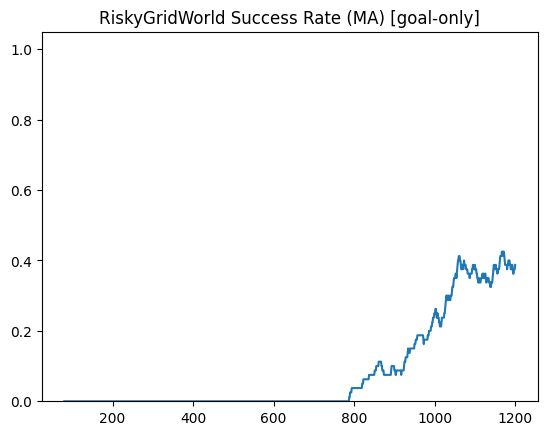

end_reason
trap     799
enemy    294
goal     107
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_risky["episode"], df_risky["return_ma"])
plt.title("RiskyGridWorld Return (MA)")
plt.show()

plt.figure()
plt.plot(df_risky["episode"], df_risky["success_rate_ma"])
plt.title("RiskyGridWorld Success Rate (MA) [goal-only]")
plt.ylim(0,1.05)
plt.show()

df_risky["end_reason"].value_counts()

In [9]:
def manhattan(a_rc, b_rc):
    return abs(a_rc[0] - b_rc[0]) + abs(a_rc[1] - b_rc[1])

def extract_agent_pos(state):
    # state = (ar, ac, er, ec)
    return (state[0], state[1])

In [10]:
def train_qlearning_risky(
    env,
    agent,
    num_episodes=1200,
    max_steps=300,
    reward_avg_window=80,
    seed=0,
    shaping=False,
    shaping_k=0.6,   
):
    rng = np.random.default_rng(seed)
    returns, steps_list, success_list, end_reason = [], [], [], []

    goal_rc = env.goal

    for ep in range(num_episodes):
        s = env.reset()
        total_r = 0.0
        reason = "timeout"
        success = 0

        for t in range(max_steps):
            # epsilon-greedy
            if rng.random() < agent.epsilon:
                a = int(rng.choice(agent.actions))
            else:
                agent._ensure_state(s)
                a = int(agent.actions[int(np.argmax(agent.Q[s]))])

            # before step distance
            if shaping:
                d_old = manhattan(extract_agent_pos(s), goal_rc)

            res = env.step(a)
            r = res.reward

            # after step shaping
            if shaping and (not res.done):
                d_new = manhattan(extract_agent_pos(res.next_state), goal_rc)
                r = r + shaping_k * (d_old - d_new)

            agent.update(s, a, r, res.next_state, res.done)

            total_r += r
            s = res.next_state

            if res.done:
                if res.info.get("goal", False):
                    success = 1; reason = "goal"
                elif res.info.get("trap", False):
                    success = 0; reason = "trap"
                elif res.info.get("enemy", False):
                    success = 0; reason = "enemy"
                else:
                    success = 0; reason = "done_other"
                break

        agent.decay_epsilon()

        returns.append(total_r)
        steps_list.append(t + 1)
        success_list.append(success)
        end_reason.append(reason)

        if (ep + 1) % 200 == 0:
            print(f"[shaping={shaping}] ep {ep+1}/{num_episodes} return={total_r:.2f} steps={t+1} eps={agent.epsilon:.3f} end={reason}")

    df = pd.DataFrame({
        "episode": np.arange(1, num_episodes+1),
        "return": returns,
        "steps": steps_list,
        "success": success_list,
        "end_reason": end_reason
    })
    df["return_ma"] = df["return"].rolling(reward_avg_window).mean()
    df["success_rate_ma"] = df["success"].rolling(reward_avg_window).mean()
    return df

## 5. Ablation: reward shaping

Here I compare **no shaping** vs **with shaping**.

Why shaping helps here:
- Without shaping, the agent often needs many episodes before it reliably discovers a safe corridor to the goal.
- With shaping, the agent gets denser feedback (still consistent with the task objective), which improves learning speed and success rate.

I report both curves and also summarize the end reasons.

[shaping=False] ep 200/1200 return=-29.70 steps=12 eps=0.367 end=trap
[shaping=False] ep 400/1200 return=-27.40 steps=16 eps=0.135 end=trap
[shaping=False] ep 600/1200 return=-27.80 steps=20 eps=0.050 end=enemy
[shaping=False] ep 800/1200 return=-42.90 steps=108 eps=0.050 end=enemy
[shaping=False] ep 1000/1200 return=-26.70 steps=18 eps=0.050 end=trap
[shaping=False] ep 1200/1200 return=10.60 steps=86 eps=0.050 end=goal
[shaping=True] ep 200/1200 return=-24.40 steps=10 eps=0.367 end=trap
[shaping=True] ep 400/1200 return=-25.10 steps=8 eps=0.135 end=enemy
[shaping=True] ep 600/1200 return=23.50 steps=26 eps=0.050 end=goal
[shaping=True] ep 800/1200 return=24.20 steps=19 eps=0.050 end=goal
[shaping=True] ep 1000/1200 return=26.10 steps=18 eps=0.050 end=goal
[shaping=True] ep 1200/1200 return=25.10 steps=19 eps=0.050 end=goal


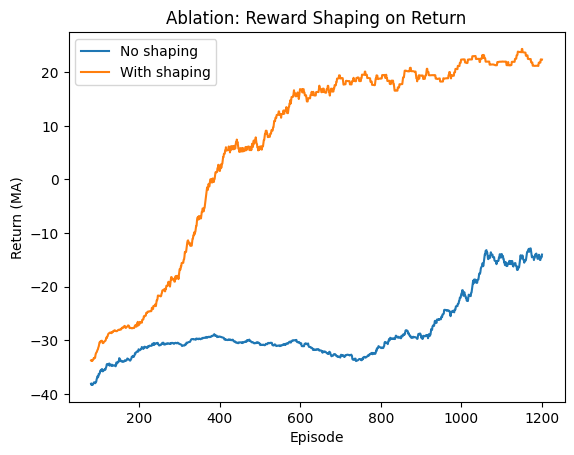

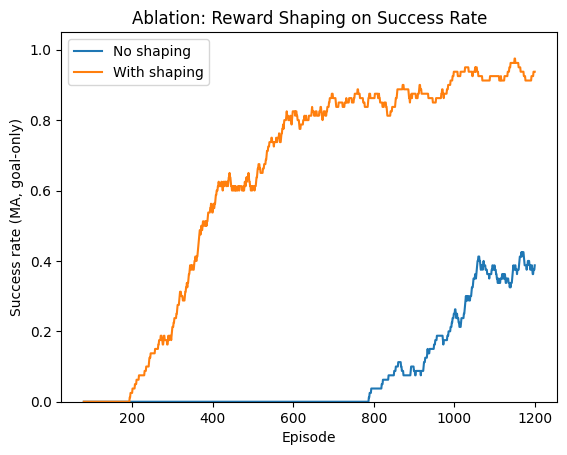

No shaping end_reason counts:
 end_reason
trap     799
enemy    294
goal     107
Name: count, dtype: int64

With shaping end_reason counts:
 end_reason
goal     750
trap     291
enemy    159
Name: count, dtype: int64


In [11]:
# same environment
envA = RiskyGridWorld(
    grid_size=8, obstacle_prob=0.2, trap_prob=0.2,
    enemy_enabled=True, enemy_policy="random",
    seed=1,
    step_reward=-0.1, goal_reward=20.0, invalid_penalty=-1.0,
    trap_penalty=-25.0, enemy_penalty=-25.0
)

# Run 1: no shaping
agentA = QLearningAgent(actions=envA.actions, alpha=0.2, gamma=0.95,
                        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995)
df_no = train_qlearning_risky(envA, agentA, num_episodes=1200, max_steps=300,
                             reward_avg_window=80, seed=1, shaping=False)

# Run 2: with shaping (same env seed -> recreate env)
envB = RiskyGridWorld(
    grid_size=8, obstacle_prob=0.2, trap_prob=0.2,
    enemy_enabled=True, enemy_policy="random",
    seed=1,
    step_reward=-0.1, goal_reward=20.0, invalid_penalty=-1.0,
    trap_penalty=-25.0, enemy_penalty=-25.0
)
agentB = QLearningAgent(actions=envB.actions, alpha=0.2, gamma=0.95,
                        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995)
df_yes = train_qlearning_risky(envB, agentB, num_episodes=1200, max_steps=300,
                              reward_avg_window=80, seed=1, shaping=True, shaping_k=0.6)

df_no.to_csv("risky_no_shaping.csv", index=False)
df_yes.to_csv("risky_with_shaping.csv", index=False)

# plot compare
plt.figure()
plt.plot(df_no["episode"], df_no["return_ma"], label="No shaping")
plt.plot(df_yes["episode"], df_yes["return_ma"], label="With shaping")
plt.xlabel("Episode"); plt.ylabel("Return (MA)")
plt.title("Ablation: Reward Shaping on Return")
plt.legend()
plt.show()

plt.figure()
plt.plot(df_no["episode"], df_no["success_rate_ma"], label="No shaping")
plt.plot(df_yes["episode"], df_yes["success_rate_ma"], label="With shaping")
plt.xlabel("Episode"); plt.ylabel("Success rate (MA, goal-only)")
plt.title("Ablation: Reward Shaping on Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

print("No shaping end_reason counts:\n", df_no["end_reason"].value_counts())
print("\nWith shaping end_reason counts:\n", df_yes["end_reason"].value_counts())

In [12]:
print("Q states learned:", len(agentB.Q))
print("epsilon before demo:", agentB.epsilon)

Q states learned: 2102
epsilon before demo: 0.05


## 6. Greedy policy rollout (qualitative demo)

After training, I run one episode using a **greedy policy** (always take `argmax_a Q(s,a)`), and print a step-by-step trace.
This is helpful to sanity-check that the learned behavior matches the intended game design (avoid traps/enemy, reach goal).

In [13]:
import time

ACTION_NAME = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT",
    4: "STAY"
}

def greedy_action(agent, state, actions):
    agent._ensure_state(state)
    return int(actions[int(np.argmax(agent.Q[state]))])

def rollout_greedy(env, agent, max_steps=80, sleep_sec=0.2, print_each_step=True):

    old_eps = agent.epsilon
    agent.epsilon = 0.0

    s = env.reset()
    total = 0.0

    print("=== Greedy Policy Demo ===")
    print(env.render_ascii())
    print("Initial state:", s)
    print("--------------------------")

    for t in range(max_steps):
        a = greedy_action(agent, s, env.actions)
        res = env.step(a)
        total += res.reward

        if print_each_step:
            print(f"step {t+1:02d}  action={ACTION_NAME[a]:5s}  reward={res.reward:6.2f}  info={res.info}")
            print(env.render_ascii())
            print("--------------------------")

      
        if sleep_sec and sleep_sec > 0:
            time.sleep(sleep_sec)

        s = res.next_state
        if res.done:
            if res.info.get("goal", False):
                print(f"Reached GOAL in {t+1} steps. Total reward = {total:.2f}")
            elif res.info.get("trap", False):
                print(f"Fell into TRAP in {t+1} steps. Total reward = {total:.2f}")
            elif res.info.get("enemy", False):
                print(f"Caught by ENEMY in {t+1} steps. Total reward = {total:.2f}")
            else:
                print(f"Done (other) in {t+1} steps. Total reward = {total:.2f}")
            break
    else:
        print(f"⏱️ Timeout after {max_steps} steps. Total reward = {total:.2f}")

    agent.epsilon = old_eps


rollout_greedy(envB, agentB, max_steps=80, sleep_sec=0.0, print_each_step=True)

=== Greedy Policy Demo ===
A . . T . . E .
. # . . . . # .
. . . T . . T .
# . # . . . # T
# . . # . . T .
T . . . . . # .
. . # . . . # .
. . . . . . . G
Initial state: (0, 0, 0, 6)
--------------------------
step 01  action=DOWN   reward= -0.10  info={}
S . . T . E . .
A # . . . . # .
. . . T . . T .
# . # . . . # T
# . . # . . T .
T . . . . . # .
. . # . . . # .
. . . . . . . G
--------------------------
step 02  action=DOWN   reward= -0.10  info={}
S . . T . . . .
. # . . . E # .
A . . T . . T .
# . # . . . # T
# . . # . . T .
T . . . . . # .
. . # . . . # .
. . . . . . . G
--------------------------
step 03  action=RIGHT  reward= -0.10  info={}
S . . T . E . .
. # . . . . # .
. A . T . . T .
# . # . . . # T
# . . # . . T .
T . . . . . # .
. . # . . . # .
. . . . . . . G
--------------------------
step 04  action=DOWN   reward= -0.10  info={}
S . . T . E . .
. # . . . . # .
. . . T . . T .
# A # . . . # T
# . . # . . T .
T . . . . . # .
. . # . . . # .
. . . . . . . G
-------------

In [14]:
import matplotlib.pyplot as plt
import numpy as np

CELL = {".":0, "#":1, "T":2, "S":3, "G":4, "E":5, "A":6}

def grid_to_array(env):
    lines = env.render_ascii().split("\n")
    arr = np.zeros((env.grid_size, env.grid_size), dtype=int)
    for r, line in enumerate(lines):
        tokens = line.split()
        for c, ch in enumerate(tokens):
            arr[r, c] = CELL.get(ch, 0)
    return arr

def rollout_frames(env, agent, max_steps=80):
    old_eps = agent.epsilon
    agent.epsilon = 0.0
    s = env.reset()
    frames = [grid_to_array(env)]
    infos = []

    for t in range(max_steps):
        a = greedy_action(agent, s, env.actions)
        res = env.step(a)
        infos.append((t+1, a, res.reward, res.info))
        frames.append(grid_to_array(env))
        s = res.next_state
        if res.done:
            break

    agent.epsilon = old_eps
    return frames, infos

frames, infos = rollout_frames(envB, agentB, max_steps=80)
print("frames:", len(frames), "steps:", len(infos))

frames: 18 steps: 17


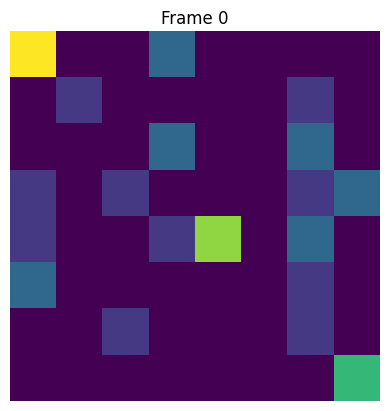

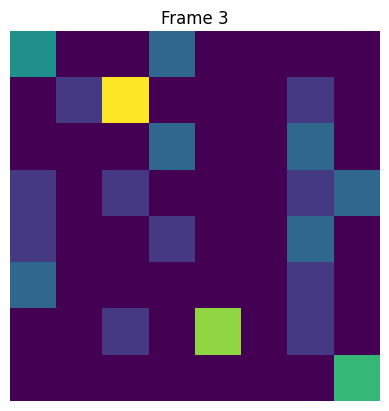

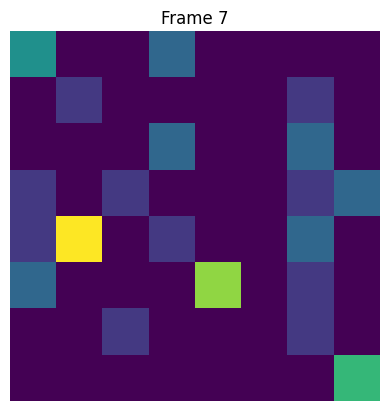

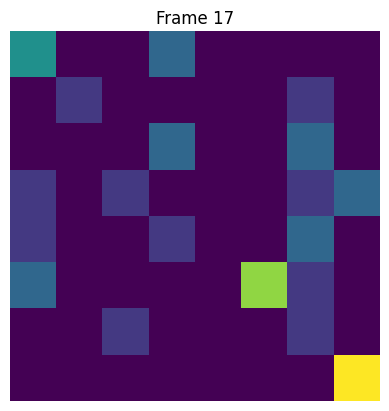

Last step info: (17, 3, 20.0, {'goal': True})


In [15]:
for i in [0, 3, 7, len(frames)-1]:
    plt.figure()
    plt.imshow(frames[i])
    plt.title(f"Frame {i}")
    plt.axis("off")
    plt.show()

print("Last step info:", infos[-1])

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

LABELS = {
    0: ("Empty", "."),
    1: ("Wall", "#"),
    2: ("Trap", "T"),
    3: ("Start", "S"),
    4: ("Goal", "G"),
    5: ("Enemy", "E"),
    6: ("Agent", "A"),
}


cmap = ListedColormap([
    "#2b1055",  # empty
    "#6c6c6c",  # wall
    "#d62728",  # trap
    "#1f77b4",  # start
    "#2ca02c",  # goal
    "#ff7f0e",  # enemy
    "#ffd700",  # agent
])
norm = BoundaryNorm(np.arange(-0.5, 7.5, 1), cmap.N)

legend_patches = [
    mpatches.Patch(color=cmap(i), label=LABELS[i][0])
    for i in range(7)
]

def show_frame(arr, title=""):
    plt.figure(figsize=(5,5))
    plt.imshow(arr, cmap=cmap, norm=norm)
    plt.title(title)
    plt.axis("off")
    plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

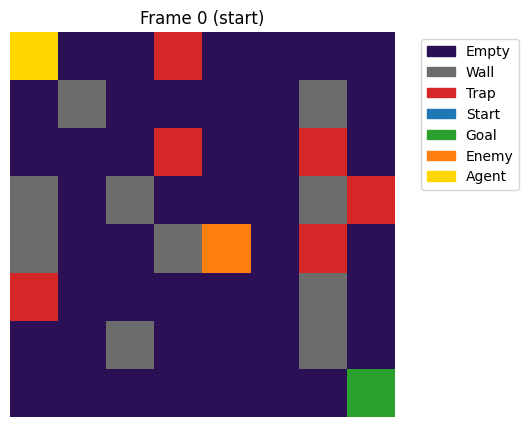

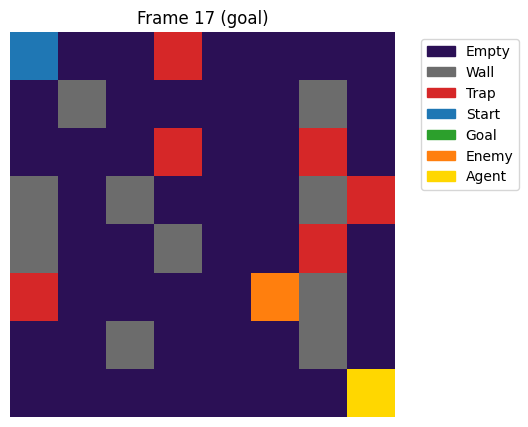

In [17]:
show_frame(frames[0], "Frame 0 (start)")
show_frame(frames[-1], f"Frame {len(frames)-1} (goal)")

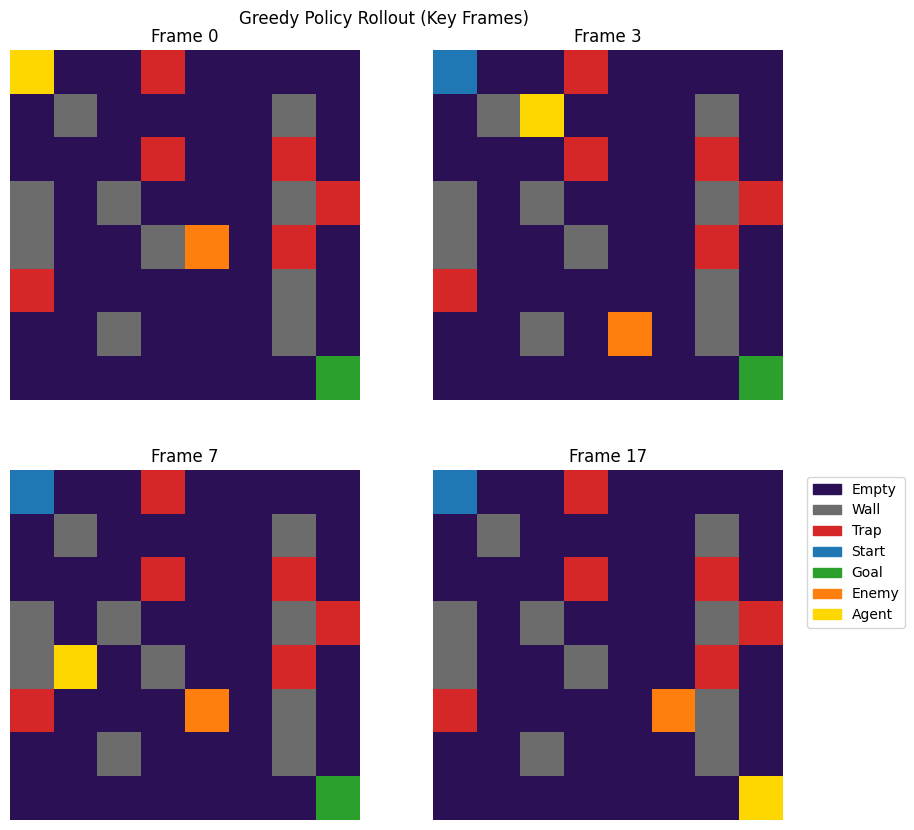

In [18]:
def show_summary(frames, indices=None):
    if indices is None:
        indices = [0, 3, 7, len(frames)-1]

    plt.figure(figsize=(10,10))
    for i, idx in enumerate(indices, 1):
        plt.subplot(2,2,i)
        plt.imshow(frames[idx], cmap=cmap, norm=norm)
        plt.title(f"Frame {idx}")
        plt.axis("off")

    plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.suptitle("Greedy Policy Rollout (Key Frames)", y=0.92)
    plt.show()

show_summary(frames, indices=[0, 3, 7, len(frames)-1])

## 7. Export: rollout GIF

For the submission, I also render the greedy rollout into a short GIF. This is useful for the report/video.

In [19]:
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

def save_gif(frames, path="rollout.gif", fps=4):
    imgs = []
    for idx, arr in enumerate(frames):
        fig = plt.figure(figsize=(5,5))
        plt.imshow(arr, cmap=cmap, norm=norm)
        plt.title(f"Frame {idx}")
        plt.axis("off")

        fig.canvas.draw()


        rgba = np.asarray(fig.canvas.buffer_rgba())
        rgb = rgba[..., :3].copy()   # drop alpha channel
        imgs.append(rgb)

        plt.close(fig)

    imageio.mimsave(path, imgs, fps=fps)
    print("saved", path)

save_gif(frames, "rollout.gif", fps=4)

saved rollout.gif


In [20]:
ACTION_NAME = {0:"UP", 1:"DOWN", 2:"LEFT", 3:"RIGHT", 4:"STAY"}

def greedy_action(agent, state, actions):
    agent._ensure_state(state)
    return int(actions[int(np.argmax(agent.Q[state]))])

def ui_autoplay_demo(env, agent, max_steps=80, delay=0.25):
    old_eps = agent.epsilon
    agent.epsilon = 0.0

    s = env.reset()
    total = 0.0

    for t in range(max_steps):
        a = greedy_action(agent, s, env.actions)
        res = env.step(a)
        total += res.reward

        # render
        arr = grid_to_array(env)
        plt.figure(figsize=(5,5))
        plt.imshow(arr, cmap=cmap, norm=norm)
        plt.axis("off")

        title = f"Step {t+1} | a={ACTION_NAME[a]} | r={res.reward:.2f} | return={total:.2f}"
        if res.done:
            if res.info.get("goal", False): title += " | DONE: GOAL "
            elif res.info.get("trap", False): title += " | DONE: TRAP "
            elif res.info.get("enemy", False): title += " | DONE: ENEMY "
            else: title += " | DONE"
        plt.title(title)

        plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.show()

        # next
        s = res.next_state
        if res.done:
            break

        # delay
        import time
        time.sleep(delay)
        from IPython.display import clear_output
        clear_output(wait=True)

    agent.epsilon = old_eps
    print("Demo finished. Total return:", round(total, 2))

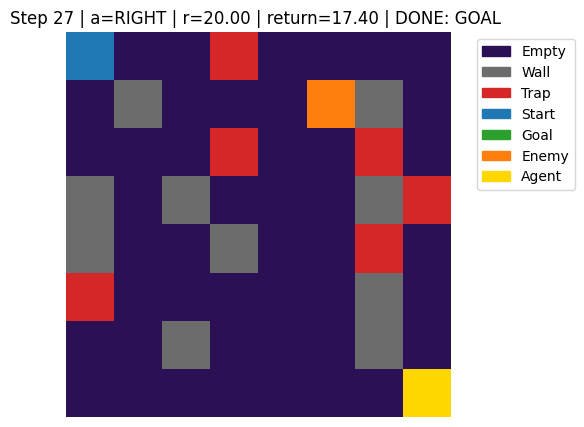

Demo finished. Total return: 17.4


In [21]:
ui_autoplay_demo(envB, agentB, max_steps=80, delay=0.2)

In [22]:
!pip -q install ipywidgets


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


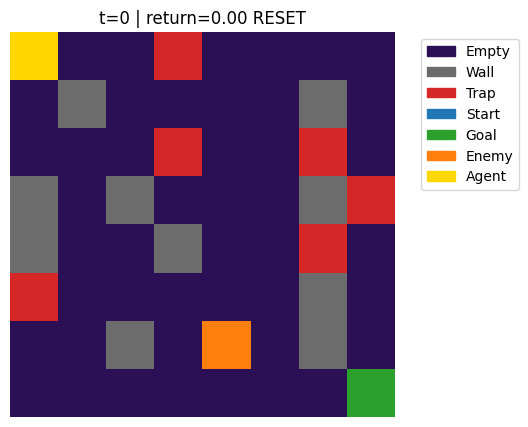

In [23]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

def make_interactive_ui(env, agent):
    old_eps = agent.epsilon
    agent.epsilon = 0.0

    state = {
        "s": None,
        "total": 0.0,
        "t": 0,
        "done": False,
        "playing": False
    }

    def reset(_=None):
        state["s"] = env.reset()
        state["total"] = 0.0
        state["t"] = 0
        state["done"] = False
        state["playing"] = False
        render("RESET")

    def render(extra=""):
        clear_output(wait=True)
        arr = grid_to_array(env)
        plt.figure(figsize=(5,5))
        plt.imshow(arr, cmap=cmap, norm=norm)
        plt.axis("off")
        plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.title(f"t={state['t']} | return={state['total']:.2f} {extra}")
        plt.show()
        display(ui_box)

    def step_once(_=None):
        if state["done"]:
            render("DONE")
            return

        a = greedy_action(agent, state["s"], env.actions)
        res = env.step(a)

        state["total"] += res.reward
        state["t"] += 1
        state["s"] = res.next_state

        if res.done:
            state["done"] = True
            if res.info.get("goal", False):
                render(f"| a={ACTION_NAME[a]} r={res.reward:.2f} ✅ GOAL")
            elif res.info.get("trap", False):
                render(f"| a={ACTION_NAME[a]} r={res.reward:.2f} 💥 TRAP")
            elif res.info.get("enemy", False):
                render(f"| a={ACTION_NAME[a]} r={res.reward:.2f} ☠️ ENEMY")
            else:
                render("DONE")
        else:
            render(f"| a={ACTION_NAME[a]} r={res.reward:.2f}")

    def autoplay(_=None):
        state["playing"] = True
        run_autoplay()

    def run_autoplay():
        if not state["playing"] or state["done"]:
            return

        step_once()
        time.sleep(speed_slider.value)

        if state["playing"] and not state["done"]:
            run_autoplay()

    def pause(_=None):
        state["playing"] = False
        render("(paused)")

    reset_btn = widgets.Button(description="Reset", button_style="info")
    step_btn  = widgets.Button(description="Step", button_style="primary")
    play_btn  = widgets.Button(description="Auto Play", button_style="success")
    pause_btn = widgets.Button(description="Pause", button_style="warning")
    speed_slider = widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description="Delay")

    reset_btn.on_click(reset)
    step_btn.on_click(step_once)
    play_btn.on_click(autoplay)
    pause_btn.on_click(pause)

    global ui_box
    ui_box = widgets.VBox([
        widgets.HBox([reset_btn, step_btn, play_btn, pause_btn]),
        speed_slider
    ])

    reset()

make_interactive_ui(envB, agentB)

## 8. Export: Q-table for the interactive UI

Finally I export the learned Q-table to `qtable.pkl`. The pygame UI loads this file and lets the user:
- play manually (human)
- watch the learned policy (AI)
- step the AI one action at a time for explanation


In [24]:
import pickle
with open("qtable.pkl", "wb") as f:
    pickle.dump(agentB.Q, f)
print("saved qtable.pkl")

saved qtable.pkl


### Done

At this point the training artifacts are ready. Next, run the pygame demo (`CDS524_Assignment1_LIUZirui.py`) to interact with the environment and the learned policy.